In [1]:
# %% [markdown]
# # HydroSOS Streamflow Status Product Methodology
# #### Jose Valles (jose.valles.leon@gmail.com)

# %% [markdown]
# ## One month status product
# 
# ### Importing the data and finding missing dates

# %%
# Importing the libraries
from unittest import result

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm 
import argparse 
import locale
plt.style.use('classic')

sns.set()

locale.setlocale(locale.LC_TIME, "es_ES")

'es_ES'

In [2]:
# Define arguments 
'''
parser = argparse.ArgumentParser(
                    prog='calculate_hydrological_status',
                    description='Plot ESP outlook from codcuenca n2',
                    epilog='Jose Valles, DINAGUA, 26082024')

# 
parser.add_argument('end_date', help='end date for the discharge plot in format YYYY-MM-DD')      

args = parser.parse_args()
'''

args = argparse.Namespace(
    end_date='2026-08-01'
)

In [3]:
# %%
class EstadoHidrologico:
    def __init__(self, station_name,values,flow_cat):
        self.station_name = station_name
        self.values = values
        self.flow_cat = flow_cat
        self.DISCHARGE_MONTHLY = None

    def cargar_datos(self):
        self.DISCHARGE_MONTHLY = pd.read_csv(f'../waterbalance/input/{self.station_name}.csv',parse_dates=['Fecha'],index_col="Fecha",dayfirst=True,na_values="NA")
        self.DISCHARGE_MONTHLY['year'] = self.DISCHARGE_MONTHLY.index.year
        self.DISCHARGE_MONTHLY['month'] = self.DISCHARGE_MONTHLY.index.month
        self.DISCHARGE_MONTHLY['water_year'] = self.DISCHARGE_MONTHLY.index.year.where(self.DISCHARGE_MONTHLY.index.month < 4, self.DISCHARGE_MONTHLY.index.year + 1)
        self.DISCHARGE_MONTHLY.index = self.DISCHARGE_MONTHLY.index.map(lambda t: t.replace(day=1))
        return self.DISCHARGE_MONTHLY

    def estado_mensual(self):
        # Climatologia
        DISCHARGE_SELECTION = self.DISCHARGE_MONTHLY[(self.DISCHARGE_MONTHLY['year'] >= 1981) & (self.DISCHARGE_MONTHLY['year'] <= 2010)]
        DISCHARGE_AVERAGE = DISCHARGE_SELECTION.groupby(DISCHARGE_SELECTION.month).mean()
        DISCHARGE_AVERAGE = DISCHARGE_AVERAGE.reindex(columns=['Caudal'])
        # Calcular indicadores
        self.DISCHARGE_MONTHLY['average_percentage'] = np.nan
        self.DISCHARGE_MONTHLY['rank_average'] = np.nan
        self.DISCHARGE_MONTHLY['non_missing'] = np.nan

        for i in range(len(self.DISCHARGE_MONTHLY)):
            # Extract the current month 
            m = self.DISCHARGE_MONTHLY.month[i]
            # Extract the current year
            y = self.DISCHARGE_MONTHLY.year[i]
            self.DISCHARGE_MONTHLY.loc[self.DISCHARGE_MONTHLY.eval('month==@m & year==@y'),'rank_average']  = self.DISCHARGE_MONTHLY.query('month==@m')['Caudal'].rank()
            self.DISCHARGE_MONTHLY.loc[self.DISCHARGE_MONTHLY.eval('month==@m & year==@y'),'non_missing']  = self.DISCHARGE_MONTHLY.query('month==@m')["Caudal"].notnull().sum()
            self.DISCHARGE_MONTHLY.loc[self.DISCHARGE_MONTHLY.eval('month==@m & year==@y'),'average_percentage'] = (self.DISCHARGE_MONTHLY['Caudal'][i] - DISCHARGE_AVERAGE.query('month == @m')["Caudal"].item()) / DISCHARGE_AVERAGE.query('month == @m')["Caudal"].item()

        # Percentile position using the Weibull (alphap = 0.0 , betap = 0.0) or Cunnane (alphap = 0.4 , betap = 0.4) plotting position formula
        alphap = 0.4
        betap = 0.4
        self.DISCHARGE_MONTHLY['percentile'] = (self.DISCHARGE_MONTHLY['rank_average'] - alphap) / (self.DISCHARGE_MONTHLY['non_missing'] + 1 - alphap - betap)

        criteria = [self.DISCHARGE_MONTHLY['percentile'].between(0.90,1.00),
            self.DISCHARGE_MONTHLY['percentile'].between(0.75,0.90),
            self.DISCHARGE_MONTHLY['percentile'].between(0.25,0.75),
            self.DISCHARGE_MONTHLY['percentile'].between(0.10,0.25),
            self.DISCHARGE_MONTHLY['percentile'].between(0.00,0.10)]

        self.DISCHARGE_MONTHLY['percentile_range'] = np.select(criteria,self.values,None)
        self.DISCHARGE_MONTHLY['flowcat'] = np.select(criteria,self.flow_cat,pd.NA)

        return self.DISCHARGE_MONTHLY
    
    def estado_trimestral(self):
        # Agregar caudales
        DISCHARGE_THREE_MONTHS = pd.DataFrame(self.DISCHARGE_MONTHLY['Caudal'].rolling(3).apply(lambda x: x.mean() if x.isnull().sum()*100/len(x) < 0.5 else np.nan))
        # Agregar columnas
        DISCHARGE_THREE_MONTHS['startMonth'] = (DISCHARGE_THREE_MONTHS.index - pd.DateOffset(months=2)).month
        DISCHARGE_THREE_MONTHS['endMonth'] = DISCHARGE_THREE_MONTHS.index.month
        DISCHARGE_THREE_MONTHS['year'] = DISCHARGE_THREE_MONTHS.index.year
        DISCHARGE_THREE_MONTHS.index = DISCHARGE_THREE_MONTHS.index.map(lambda t: t.replace(day=1))
        # Climatologia
        DISCHARGE_SELECTION_THREE_MONTH = DISCHARGE_THREE_MONTHS[(DISCHARGE_THREE_MONTHS['year'] >= 1981) & (DISCHARGE_THREE_MONTHS['year'] < 2010)]
        DISCHARGE_AVERAGE_THREE_MONTH = DISCHARGE_SELECTION_THREE_MONTH.groupby(DISCHARGE_SELECTION_THREE_MONTH.startMonth).mean()
        DISCHARGE_AVERAGE_THREE_MONTH = DISCHARGE_AVERAGE_THREE_MONTH.reindex(columns=['Caudal'])
        # Calcular indicadores
        DISCHARGE_THREE_MONTHS['average_percentage'] = np.nan
        DISCHARGE_THREE_MONTHS['rank_average'] = np.nan
        DISCHARGE_THREE_MONTHS['non_missing'] = np.nan

        for i in range(len(DISCHARGE_THREE_MONTHS)):
            # Extract the current month 
            m = DISCHARGE_THREE_MONTHS.startMonth[i]
            # Extract the current year
            y = DISCHARGE_THREE_MONTHS.year[i]
            DISCHARGE_THREE_MONTHS.loc[DISCHARGE_THREE_MONTHS.eval('startMonth==@m & year==@y'),'rank_average']  = DISCHARGE_THREE_MONTHS.query('startMonth==@m')['Caudal'].rank()
            DISCHARGE_THREE_MONTHS.loc[DISCHARGE_THREE_MONTHS.eval('startMonth==@m & year==@y'),'non_missing']  = DISCHARGE_THREE_MONTHS.query('startMonth==@m')["Caudal"].notnull().sum()
            DISCHARGE_THREE_MONTHS.loc[DISCHARGE_THREE_MONTHS.eval('startMonth==@m & year==@y'),'average_percentage'] = (DISCHARGE_THREE_MONTHS['Caudal'][i] - DISCHARGE_AVERAGE_THREE_MONTH.query('startMonth == @m')["Caudal"].item()) / DISCHARGE_AVERAGE_THREE_MONTH.query('startMonth == @m')["Caudal"].item()

        alphap = 0.4
        betap = 0.4
        DISCHARGE_THREE_MONTHS['percentile'] = (DISCHARGE_THREE_MONTHS['rank_average'] - alphap) / (DISCHARGE_THREE_MONTHS['non_missing'] + 1 - alphap - betap)

        criteria_three_months = [DISCHARGE_THREE_MONTHS['percentile'].between(0.90,1.00),
            DISCHARGE_THREE_MONTHS['percentile'].between(0.75,0.90),
            DISCHARGE_THREE_MONTHS['percentile'].between(0.25,0.75),
            DISCHARGE_THREE_MONTHS['percentile'].between(0.10,0.25),
            DISCHARGE_THREE_MONTHS['percentile'].between(0.00,0.10)]

        DISCHARGE_THREE_MONTHS['percentile_range'] = np.select(criteria_three_months,self.values,None)
        DISCHARGE_THREE_MONTHS['flowcat'] = np.select(criteria_three_months,self.flow_cat,pd.NA)

        row_labels = {1:'JFM',
             2:'FMA',
             3:'MAM',
             4:'AMJ',
             5:'MJJ',
             6:'JJA',
             7:'JAS',
             8:'ASO',
             9:'SON',
             10:'OND',
             11:'NDE',
             12:'DEF'}
        
        DISCHARGE_THREE_MONTHS['period'] = DISCHARGE_THREE_MONTHS['startMonth'].replace(row_labels) 
        return DISCHARGE_THREE_MONTHS
    
    def estado_anual(self):
        # Agrgar caudales
        DISCHARGE_TWELVE_MONTHS = pd.DataFrame(self.DISCHARGE_MONTHLY['Caudal'].rolling(12).apply(lambda x: x.mean() if x.isnull().sum()*100/len(x) < 0.5 else np.nan))
        DISCHARGE_TWELVE_MONTHS['startMonth'] = (DISCHARGE_TWELVE_MONTHS.index - pd.DateOffset(months=2)).month
        DISCHARGE_TWELVE_MONTHS['endMonth'] = DISCHARGE_TWELVE_MONTHS.index.month
        DISCHARGE_TWELVE_MONTHS['year'] = DISCHARGE_TWELVE_MONTHS.index.year
        DISCHARGE_TWELVE_MONTHS.index = DISCHARGE_TWELVE_MONTHS.index.map(lambda t: t.replace(day=1))
        # Climatologia
        DISCHARGE_SELECTION_TWELVE_MONTH = DISCHARGE_TWELVE_MONTHS[(DISCHARGE_TWELVE_MONTHS['year'] >= 1981) & (DISCHARGE_TWELVE_MONTHS['year'] < 2010)]
        DISCHARGE_AVERAGE_TWELVE_MONTH = DISCHARGE_SELECTION_TWELVE_MONTH.groupby(DISCHARGE_SELECTION_TWELVE_MONTH.startMonth).mean()
        DISCHARGE_AVERAGE_TWELVE_MONTH = DISCHARGE_AVERAGE_TWELVE_MONTH.reindex(columns=['Caudal'])
        # Calcular indice
        DISCHARGE_TWELVE_MONTHS['average_percentage'] = np.nan
        DISCHARGE_TWELVE_MONTHS['rank_average'] = np.nan
        DISCHARGE_TWELVE_MONTHS['non_missing'] = np.nan

        for i in range(len(DISCHARGE_TWELVE_MONTHS)):
            # Extract the current month 
            m = DISCHARGE_TWELVE_MONTHS.startMonth[i]
            # Extract the current year
            y = DISCHARGE_TWELVE_MONTHS.year[i]
            DISCHARGE_TWELVE_MONTHS.loc[DISCHARGE_TWELVE_MONTHS.eval('startMonth==@m & year==@y'),'rank_average']  = DISCHARGE_TWELVE_MONTHS.query('startMonth==@m')['Caudal'].rank()
            DISCHARGE_TWELVE_MONTHS.loc[DISCHARGE_TWELVE_MONTHS.eval('startMonth==@m & year==@y'),'non_missing']  = DISCHARGE_TWELVE_MONTHS.query('startMonth==@m')["Caudal"].notnull().sum()
            DISCHARGE_TWELVE_MONTHS.loc[DISCHARGE_TWELVE_MONTHS.eval('startMonth==@m & year==@y'),'average_percentage'] = (DISCHARGE_TWELVE_MONTHS['Caudal'][i] - DISCHARGE_AVERAGE_TWELVE_MONTH.query('startMonth == @m')["Caudal"].item()) / DISCHARGE_AVERAGE_TWELVE_MONTH.query('startMonth == @m')["Caudal"].item()
    
        alphap = 0.4
        betap = 0.4
        DISCHARGE_TWELVE_MONTHS['percentile'] = (DISCHARGE_TWELVE_MONTHS['rank_average'] - alphap) / (DISCHARGE_TWELVE_MONTHS['non_missing'] + 1 - alphap - betap)

        criteria_twelve_months = [DISCHARGE_TWELVE_MONTHS['percentile'].between(0.90,1.00),
            DISCHARGE_TWELVE_MONTHS['percentile'].between(0.75,0.90),
            DISCHARGE_TWELVE_MONTHS['percentile'].between(0.25,0.75),
            DISCHARGE_TWELVE_MONTHS['percentile'].between(0.10,0.25),
            DISCHARGE_TWELVE_MONTHS['percentile'].between(0.00,0.10)]

        DISCHARGE_TWELVE_MONTHS['percentile_range'] = np.select(criteria_twelve_months,self.values,None)
        DISCHARGE_TWELVE_MONTHS['flowcat'] = np.select(criteria_twelve_months,self.flow_cat,pd.NA)
        return DISCHARGE_TWELVE_MONTHS

In [4]:
# %%
# Definir la fecha de finalización para el HeatMap
fecha_fin = args.end_date
back_months = 18

# Generar la secuencia de fechas de los X meses anteriores, incluyendo el mes de la fecha de finalización
fechas = pd.date_range(end=fecha_fin, periods=back_months, freq='MS')
# Crear un DataFrame vacío con las fechas como índice
df_cat = pd.DataFrame(index=fechas)
df_cat.index.name = 'FECHA'

# Importar nombre de subcuencas
ALL_BASIN = pd.read_csv(f'../waterbalance/cuenca_nivel2.csv',index_col="Codigo")
allbasins_n2 = pd.read_csv(f'../waterbalance/cuencas_nombres.csv')

In [5]:
# %%
values = ['High flow','Above normal','Normal range','Below normal','Low flow']
flow_cat = [5,4,3,2,1]
for columna, datos in ALL_BASIN.iteritems():
    # print(columna)
    # Create model instance 
    hydro_status = EstadoHidrologico(station_name = columna,values=values,flow_cat=flow_cat)
    DISCHARGE_MONTHLY = hydro_status.cargar_datos()
    STATUS_ONE_MONTH = hydro_status.estado_mensual()
    STATUS_ONE_MONTH = STATUS_ONE_MONTH.rename_axis('date')
    # Extract categories from the last back_months variable
    df_cat[columna] = STATUS_ONE_MONTH.loc[fechas]['flowcat']
    

# %%
# Hoursecleaning 
df_cat_float = df_cat.astype(float)
df_cat_float = df_cat_float.reset_index()
piv = pd.pivot_table(df_cat_float,columns=["FECHA"])


In [6]:
 ### Plot the HeatMap

# %% Funciones para generar heatmaps de estado hidrológico

def plot_heatmap_status_simple(piv_df, df_dates, allbasins_df, output_file=None):
    """
    Genera un heatmap simple del estado hidrológico sin agrupación de cuencas.
    
    Parameters:
    -----------
    piv_df : pd.DataFrame
        Dataframe pivotado (cuencas como rows, fechas como columns)
    df_dates : pd.DataFrame
        Dataframe con columna FECHA
    allbasins_df : pd.DataFrame
        Dataframe con información de cuencas (columna 'nombre')
    output_file : str, optional
        Ruta para guardar la figura. Si es None, no guarda.
    
    Returns:
    --------
    fig, ax : matplotlib.figure.Figure, matplotlib.axes.Axes
    """
    # Definir colores y normalización
    colors = ['#CD233F', '#FFA885', '#E7E2BC', '#8ECEEE', '#2C7DCD']
    cmap = ListedColormap(colors)
    bounds = [1, 2, 3, 4, 5, 6]
    my_norm = BoundaryNorm(bounds, ncolors=len(colors))
    
    font_size = 12
    factor_delta = 2
    
    # Crear el heatmap
    fig, ax = plt.subplots(figsize=(28, 14))
    ax = sns.heatmap(piv_df, 
                     square=True, 
                     cmap=cmap, 
                     vmin=1, 
                     vmax=5,
                     annot=False,
                     norm=my_norm,
                     linewidths=1,
                     linecolor='black', 
                     ax=ax, 
                     annot_kws={'fontsize': font_size, 'fontweight': 'bold'},
                     cbar_kws={'label': '', 'orientation': 'vertical', 'shrink': 0.3})
    
    ax.set_title('Estado Hidrológico en Uruguay', pad=20, loc='center', size=18)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=90)
    
    ax.set_xlabel('Fecha', rotation=0, labelpad=10, size=font_size + factor_delta)
    ax.set_xticklabels(df_dates['FECHA'].dt.strftime('%b-%y'), fontsize=font_size + factor_delta)
    
    ax.set_ylabel('Subcuenca Hidrográfica', rotation=90, labelpad=10, fontsize=font_size + factor_delta)
    ax.tick_params(axis='y', labelsize=font_size + factor_delta)
    
    ax.set_yticklabels(allbasins_df.nombre, rotation=0)
    
    # Configurar colorbar
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticks([(b0 + b1) / 2 for b0, b1 in zip(bounds[:-1], bounds[1:])])
    colorbar.set_ticklabels(['Flujo bajo', 'Por debajo de lo normal', 'Normal', 
                             'Por encima de lo normal', 'Flujo alto'])
    colorbar.ax.tick_params(labelsize=font_size)
    colorbar.ax.yaxis.set_tick_params(rotation=0)
    colorbar.ax.yaxis.set_label_position('left')
    ax.figure.axes[-1].yaxis.label.set_size(font_size)
    
    plt.rcParams.update({'font.family': 'Arial'})
    sns.set(font_scale=1.4)
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    return fig, ax


def plot_heatmap_status_grouped(piv_df, df_dates, allbasins_df, output_file=None):
    """
    Genera un heatmap del estado hidrológico con agrupación por cuencas principales.
    
    Parameters:
    -----------
    piv_df : pd.DataFrame
        Dataframe pivotado (cuencas como rows, fechas como columns)
    df_dates : pd.DataFrame
        Dataframe con columna FECHA
    allbasins_df : pd.DataFrame
        Dataframe con información de cuencas (columna 'nombre')
    output_file : str, optional
        Ruta para guardar la figura. Si es None, no guarda.
    
    Returns:
    --------
    fig, ax : matplotlib.figure.Figure, matplotlib.axes.Axes
    """
    # Definir colores y normalización
    colors = ['#CD233F', '#FFA885', '#E7E2BC', '#8ECEEE', '#2C7DCD']
    cmap = ListedColormap(colors)
    bounds = [1, 2, 3, 4, 5, 6]
    my_norm = BoundaryNorm(bounds, ncolors=len(colors))
    
    font_size = 12
    factor_delta = 2
    ancho_linea = 2
    
    # Mapeo de grupos de cuencas
    group_map = {
        '1': 'Río Uruguay',
        '2': 'Río de la Plata',
        '3': 'Océano Atlántico',
        '4': 'Laguna Merín',
        '5': 'Río Negro',
        '6': 'Río Santa Lucia'
    }
    
    # Obtener grupos para cada fila
    basin_groups = [group_map.get(str(code)[0], "Otro") for code in piv_df.index]
    change_indices = np.where(np.array(basin_groups)[:-1] != np.array(basin_groups)[1:])[0]
    
    # Crear heatmap
    fig, ax = plt.subplots(figsize=(28, 14))
    plt.subplots_adjust(left=0.3)
    
    sns.heatmap(piv_df, square=True, cmap=cmap, norm=my_norm, linewidths=1,
                linecolor='black', ax=ax, cbar_kws={'shrink': 0.3})
    
    # Agregar etiquetas de grupo y bordes
    last_idx = 0
    x_lim_left = -1.7
    
    for idx in list(change_indices) + [len(basin_groups) - 1]:
        mid_point = (last_idx + idx + 1) / 2
        group_name = basin_groups[last_idx]
        
        ax.annotate(group_name, xy=(x_lim_left + 0.05, mid_point),
                    xycoords=('axes fraction', 'data'),
                    ha='left', va='center', fontweight='bold', fontsize=16)
        
        ax.axhline(y=idx + 1, xmin=x_lim_left, xmax=1.0,
                   color='black', linewidth=ancho_linea, clip_on=False)
        
        if last_idx == 0:
            ax.axhline(y=0, xmin=x_lim_left, xmax=1.0,
                       color='black', linewidth=ancho_linea, clip_on=False)
        
        last_idx = idx + 1
    
    # Líneas verticales
    ax.vlines(x=x_lim_left, ymin=0, ymax=len(piv_df), transform=ax.get_yaxis_transform(),
              color='black', linewidth=ancho_linea, clip_on=False)
    
    ax.vlines(x=x_lim_left + 0.5, ymin=0, ymax=len(piv_df), transform=ax.get_yaxis_transform(),
              color='black', linewidth=ancho_linea, clip_on=False)
    
    # Formateo de etiquetas
    ax.set_yticklabels(allbasins_df.nombre, rotation=0, fontsize=font_size + factor_delta)
    ax.set_xticklabels(df_dates['FECHA'].dt.strftime('%b-%y').str.upper(), fontsize=font_size + factor_delta)
    
    # Configurar colorbar
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticks([(b0 + b1) / 2 for b0, b1 in zip(bounds[:-1], bounds[1:])])
    colorbar.set_ticklabels(['Flujo bajo', 'Por debajo de lo normal', 'Normal',
                             'Por encima de lo normal', 'Flujo alto'])
    colorbar.ax.tick_params(labelsize=font_size)
    colorbar.ax.yaxis.set_tick_params(rotation=0)
    colorbar.ax.yaxis.set_label_position('left')
    ax.figure.axes[-1].yaxis.label.set_size(font_size)
    
    plt.rcParams.update({'font.family': 'Arial'})
    sns.set(font_scale=1.4)
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    return fig, ax

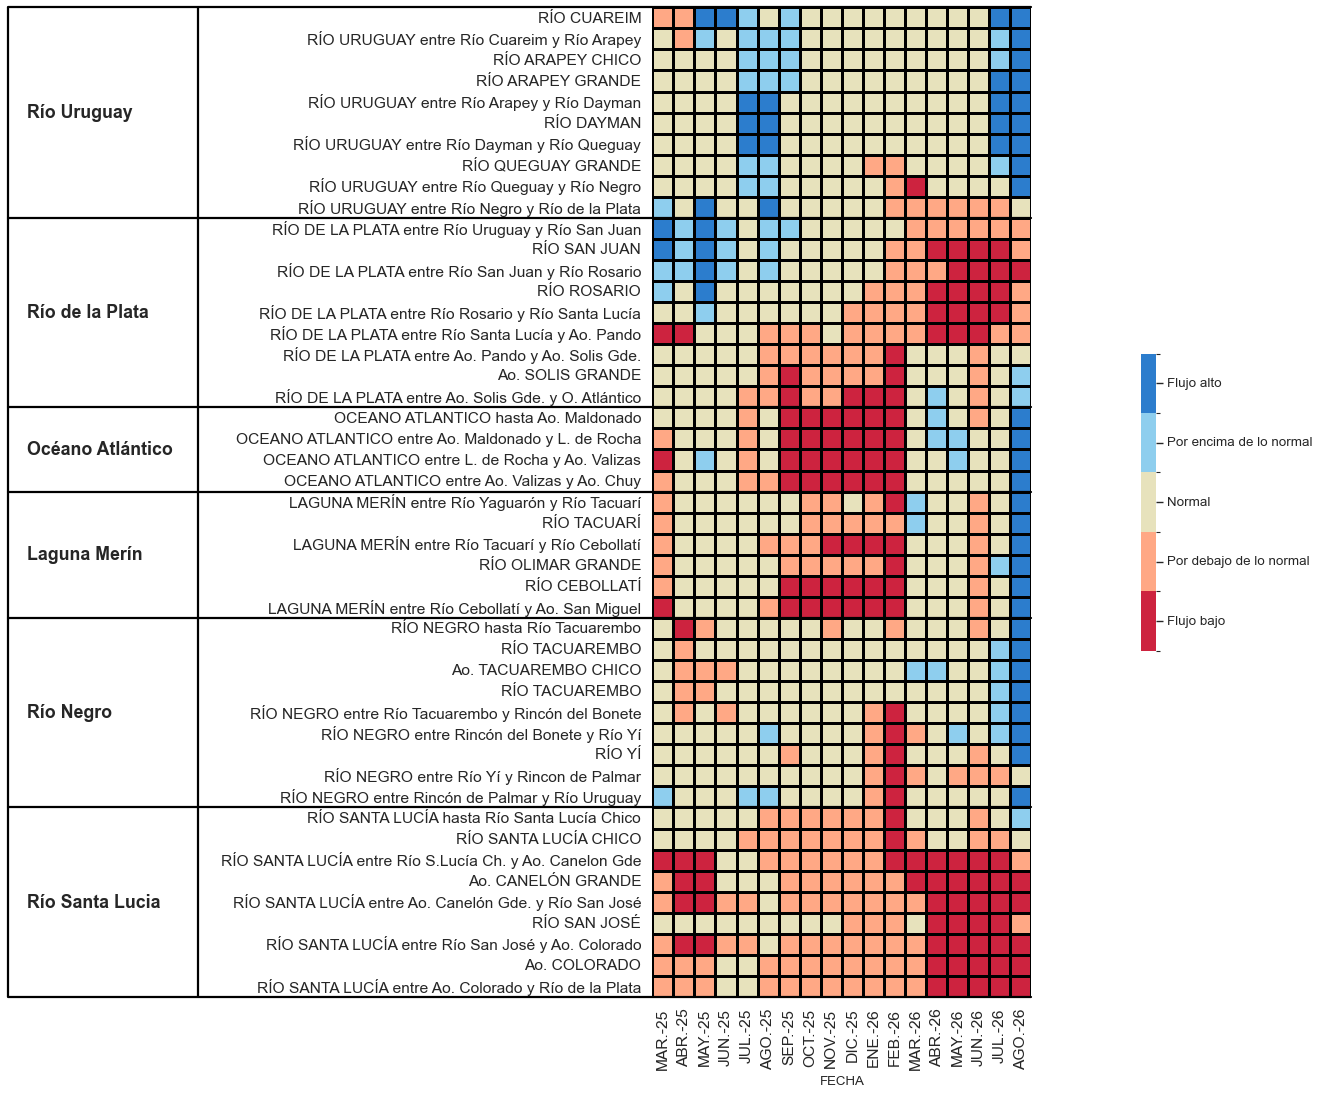

In [7]:
fig2, ax2 = plot_heatmap_status_grouped(piv, df_cat_float, allbasins_n2,
                                        output_file="")
plt.show()

In [39]:
# %% [markdown]
# ### Heatmap para una subcuenca específica
#
# Mismo heatmap que el de las 47 subcuencas (eje Y = subcuenca, eje X = últimos
# `back_months` meses), pero filtrado a UNA sola subcuenca elegida por el usuario
# (parámetro `codcuenca`).

# %%
def plot_heatmap_status_single_basin(piv_df, df_dates, allbasins_df, output_file=None):
    """
    Genera el mismo heatmap de estado hidrológico que plot_heatmap_status_simple,
    pero para una única subcuenca (piv_df debe tener una sola fila).

    Parameters:
    -----------
    piv_df : pd.DataFrame
        Dataframe pivotado filtrado a una sola subcuenca (1 row, fechas como columns)
    df_dates : pd.DataFrame
        Dataframe con columna FECHA
    allbasins_df : pd.DataFrame
        Dataframe con información de la subcuenca (columnas 'codcuenca' y 'nombre'), 1 fila
    output_file : str, optional
        Ruta para guardar la figura. Si es None, no guarda.

    Returns:
    --------
    fig, ax : matplotlib.figure.Figure, matplotlib.axes.Axes
    """
    colors = ['#CD233F', '#FFA885', '#E7E2BC', '#8ECEEE', '#2C7DCD']
    cmap = ListedColormap(colors)
    bounds = [1, 2, 3, 4, 5, 6]
    my_norm = BoundaryNorm(bounds, ncolors=len(colors))

    font_size = 14
    factor_delta = 2

    fig, ax = plt.subplots(figsize=(20, 3.5))
    sns.heatmap(piv_df, square=False, cmap=cmap, vmin=1, vmax=5, annot=False, norm=my_norm,
                linewidths=1, linecolor='black', ax=ax,
                cbar_kws={'label': '', 'orientation': 'vertical', 'shrink': 0.9})

    basin_row = allbasins_df.iloc[0]
    ax.set_title(f"Estado Hidrológico - {basin_row['nombre']} (Cuenca {basin_row['codcuenca']})",
                 pad=20, loc='center', size=18)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=90)

    ax.set_xlabel('Fecha', rotation=0, labelpad=10, size=font_size + factor_delta)
    ax.set_xticklabels(df_dates['FECHA'].dt.strftime('%b-%Y').str.upper(), fontsize=font_size + factor_delta)
    
    ax.set_ylabel('')
    # ax.set_yticklabels([basin_row['nombre']], rotation=0, fontsize=font_size + factor_delta)
    # do not show Y Label
    ax.yaxis.set_visible(False)

    colorbar = ax.collections[0].colorbar
    colorbar.set_ticks([(b0 + b1) / 2 for b0, b1 in zip(bounds[:-1], bounds[1:])])
    colorbar.set_ticklabels(['Flujo bajo', 'Por debajo de lo normal', 'Normal',
                             'Por encima de lo normal', 'Flujo alto'])
    colorbar.ax.tick_params(labelsize=font_size - 4)
    colorbar.ax.yaxis.set_tick_params(rotation=0)
    colorbar.ax.yaxis.set_label_position('left')
    ax.figure.axes[-1].yaxis.label.set_size(font_size)

    # do not show the legend

    plt.rcParams.update({'font.family': 'Arial'})
    sns.set(font_scale=1.4)
    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')

    return fig, ax





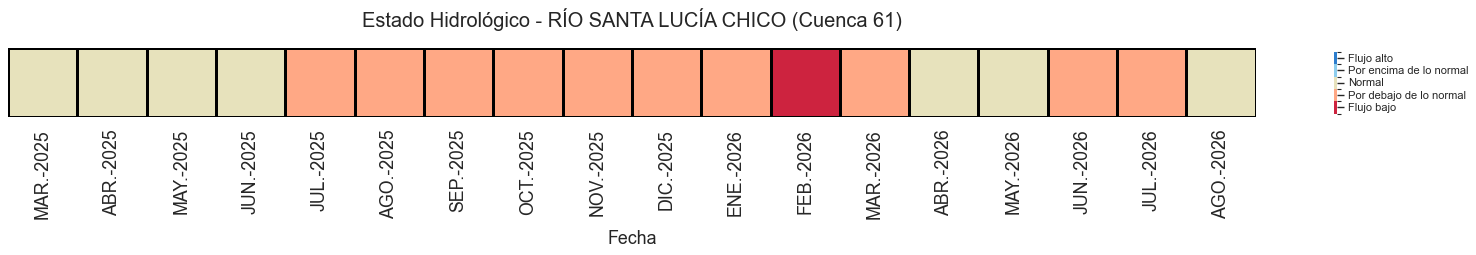

In [40]:
# %%
# Definir la subcuenca a analizar (usar uno de los códigos de allbasins_n2['codcuenca'])
codcuenca_usuario = '61'
piv_basin = piv.loc[[str(codcuenca_usuario)]]
allbasins_basin = allbasins_n2.loc[allbasins_n2['codcuenca'].astype(str) == str(codcuenca_usuario)].reset_index(drop=True)

fig3, ax3 = plot_heatmap_status_single_basin(piv_basin, df_cat_float, allbasins_basin, output_file="")
plt.show()

In [ ]:
def plot_heatmap_cuenca_eventos(station_name, 
                                eventos=None, 
                                start_month=8, 
                                end_month=4,
                                allbasins_n2 = None,
                                output_file=None):
    """
    Genera un heatmap del estado hidrológico para una cuenca específica
    cubriendo una ventana que cruza de un año al siguiente (ej. AGO año 1 a ABR año 2).
    Tamaño de figura: 28 x 14 pulgadas con tipografía aumentada.
    
    Parameters:
    -----------
    station_name : str or int
        Código de la cuenca (ej. 60 o '60').
    eventos : list of str, optional
        Lista de períodos en formato 'YYYY/YYYY' (ej. ['1982/1983', '1991/1992']).
    start_month : int, optional
        Mes de inicio en el año 1 (default: 8 para Agosto).
    end_month : int, optional
        Mes de fin en el año 2 (default: 4 para Abril).
    output_file : str, optional
        Ruta para guardar la imagen generada.
    """
    if eventos is None:
        eventos = ['1982/1983', '1991/1992', '1997/1998', '2015/2016', '2023/2024']

    # 1. Calcular el estado hidrológico mensual para la cuenca seleccionada
    values = ['High flow', 'Above normal', 'Normal range', 'Below normal', 'Low flow']
    flow_cat = [5, 4, 3, 2, 1]

    hydro = EstadoHidrologico(station_name=str(station_name), values=values, flow_cat=flow_cat)
    hydro.cargar_datos()
    df_status = hydro.estado_mensual()

    # 2. Definir la secuencia cronológica de meses a través del quiebre de año
    meses_nombres = {
        1: 'ENE', 2: 'FEB', 3: 'MAR', 4: 'ABR', 5: 'MAY', 6: 'JUN',
        7: 'JUL', 8: 'AGO', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DIC'
    }

    # Meses en el año 1 y meses en el año 2
    meses_y1 = list(range(start_month, 13))
    meses_y2 = list(range(1, end_month + 1))
    
    # Secuencia de nombres de columnas en el eje X
    cols_nombres = [meses_nombres[m] for m in (meses_y1 + meses_y2)]

    # 3. Construir la matriz (Filas = Eventos, Columnas = Meses)
    matriz = pd.DataFrame(index=eventos, columns=cols_nombres, dtype=float)

    for evento in eventos:
        y1, y2 = [int(y) for y in evento.split('/')]

        # Extraer meses del año inicial (AGO a DIC)
        for m in meses_y1:
            col_name = meses_nombres[m]
            val = df_status.loc[(df_status['year'] == y1) & (df_status['month'] == m), 'flowcat']
            if not val.empty and pd.notnull(val.values[0]):
                matriz.loc[evento, col_name] = float(val.values[0])

        # Extraer meses del año siguiente (ENE a ABR)
        for m in meses_y2:
            col_name = meses_nombres[m]
            val = df_status.loc[(df_status['year'] == y2) & (df_status['month'] == m), 'flowcat']
            if not val.empty and pd.notnull(val.values[0]):
                matriz.loc[evento, col_name] = float(val.values[0])

    # 4. Paleta y límites HydroSOS
    colors = ['#CD233F', '#FFA885', '#E7E2BC', '#8ECEEE', '#2C7DCD']
    cmap = ListedColormap(colors)
    bounds = [1, 2, 3, 4, 5, 6]
    norm = BoundaryNorm(bounds, ncolors=len(colors))

    # 5. Configuración de tamaños de fuentes y figura (28 x 14)
    font_title = 20
    font_labels = 16
    font_ticks = 14
    font_cbar = 12

    fig, ax = plt.subplots(figsize=(20, 6))

    sns.heatmap(
        matriz,
        cmap=cmap,
        norm=norm,
        linewidths=2.0,
        linecolor='black',
        square=True,
        cbar_kws={'shrink': 0.6, 'pad': 0.03},
        ax=ax
    )

    # 6. Títulos y etiquetas de los ejes
    allbasins_basin = allbasins_n2.loc[allbasins_n2['codcuenca'].astype(str) == str(station_name)].reset_index(drop=True)
    basin_row = allbasins_basin.iloc[0]
    ax.set_title(f"Estado Hidrológico - {basin_row['nombre']} (Codigo cuenca {basin_row['codcuenca']})", 
                 fontsize=font_title, fontweight='bold', pad=25)
    ax.set_xlabel('Mes', fontsize=font_labels, fontweight='bold', labelpad=15)
    ax.set_ylabel('EventoS', fontsize=font_labels, fontweight='bold', labelpad=15)

    # Configuración de los ticks de los ejes (valores X e Y)
    ax.tick_params(axis='x', rotation=0, labelsize=font_ticks)
    ax.tick_params(axis='y', rotation=0, labelsize=font_ticks)

    # 7. Configuración de la barra de colores
    cbar = ax.collections[0].colorbar
    cbar.set_ticks([(b0 + b1) / 2 for b0, b1 in zip(bounds[:-1], bounds[1:])])
    cbar.set_ticklabels(['Aguas bajas', 'Aguas medias bajas', 'Normal', 
                         'Aguas medias altas', 'Aguas altas'])
    cbar.ax.tick_params(labelsize=font_cbar)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')

    return fig, ax

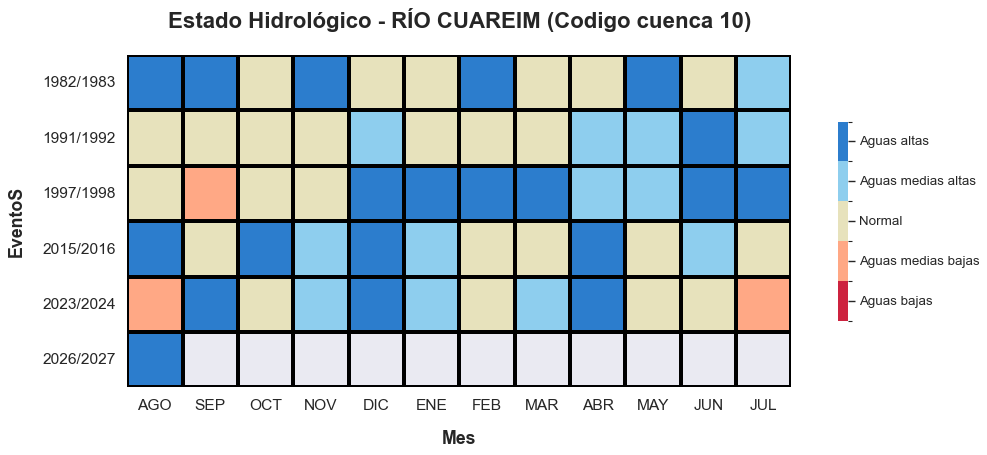

In [ ]:
# %% Ejecutar el gráfico para la cuenca 60
fig4, ax4 = plot_heatmap_cuenca_eventos(
    station_name=61,
    eventos=['1982/1983', '1991/1992', '1997/1998', '2015/2016', '2023/2024', '2026/2027'],
    start_month=8,  # Inicia en Agosto (año 1)
    end_month=7,    # Termina en Julio (año 2)
    allbasins_n2 = allbasins_n2,
    output_file=""
)
plt.show()